# ЛАБОРАТОРНА РОБОТА 2

In [180]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

## White patch

In [181]:
def white_patch(img, row, col):
  
    white = img[row, col, :]
    coeffs = 255.0 / white

    balanced = np.zeros_like(img, dtype=np.float32)

    for channel in range(3):
        balanced[..., channel] = img[..., channel] * coeffs[channel]

    balanced = balanced / 255
    balanced[balanced > 1] = 1

    return balanced

## Gray world

In [182]:
def gray_world(img):

    mean_r = np.mean(img[..., 0])
    mean_g = np.mean(img[..., 1])
    mean_b = np.mean(img[..., 2])

    max_mean = max(mean_r, mean_g, mean_b)

    kr = max_mean / mean_r
    kg = max_mean / mean_g
    kb = max_mean / mean_b

    balanced = np.zeros_like(img, dtype=np.float32)

    balanced[..., 0] = img[..., 0] * kr
    balanced[..., 1] = img[..., 1] * kg
    balanced[..., 2] = img[..., 2] * kb

    balanced = balanced / 255.0
    balanced = np.clip(balanced, 0, 1)

    return balanced

## Scale-by-max

In [183]:
def scale_by_max(img):

    max_r = np.max(img[..., 0])
    max_g = np.max(img[..., 1])
    max_b = np.max(img[..., 2])

    balanced = np.zeros_like(img, dtype=np.float32)

    balanced[..., 0] = img[..., 0] * (255.0 / max_r)
    balanced[..., 1] = img[..., 1] * (255.0 / max_g)
    balanced[..., 2] = img[..., 2] * (255.0 / max_b)

    balanced = balanced / 255.0
    balanced = np.clip(balanced, 0, 1)

    return balanced

## Результат

In [ ]:
def compare_balancing(img, row, col):

    white_patch_img = white_patch(img, row, col)
    gray_world_img = gray_world(img)
    scale_by_max_img = scale_by_max(img)

    plt.figure(figsize=(10, 8))

    plt.subplot(221)
    plt.imshow(img)
    plt.title('Original')
    plt.axis('off')

    plt.subplot(222)
    plt.imshow(white_patch_img)
    plt.title('White Patch')
    plt.axis('off')

    plt.subplot(223)
    plt.imshow(gray_world_img)
    plt.title('Gray World')
    plt.axis('off')

    plt.subplot(224)
    plt.imshow(scale_by_max_img)
    plt.title('Scale-by-Max')
    plt.axis('off')
    
    plt.show()

In [185]:
images = {
    'blue': ('blue.jpg', (600, 585)),
    'town': ('town.jpg', (485, 865)),
    'tree': ('tree.jpg', (300, 300)),
    'city': ('city.jpg', (250, 50))
}

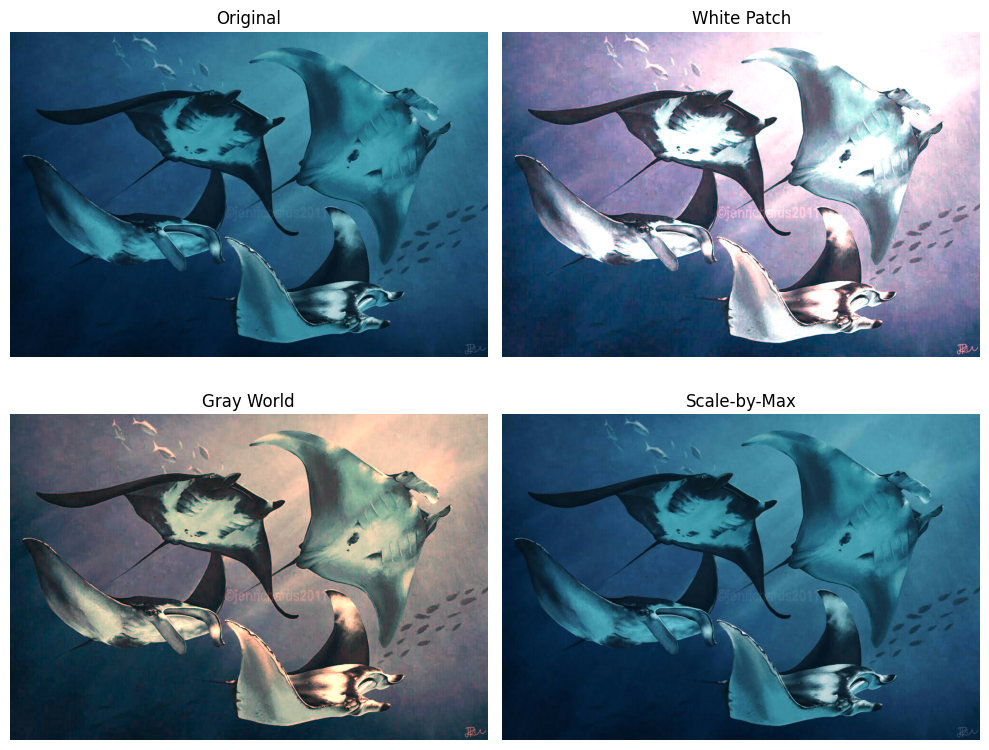

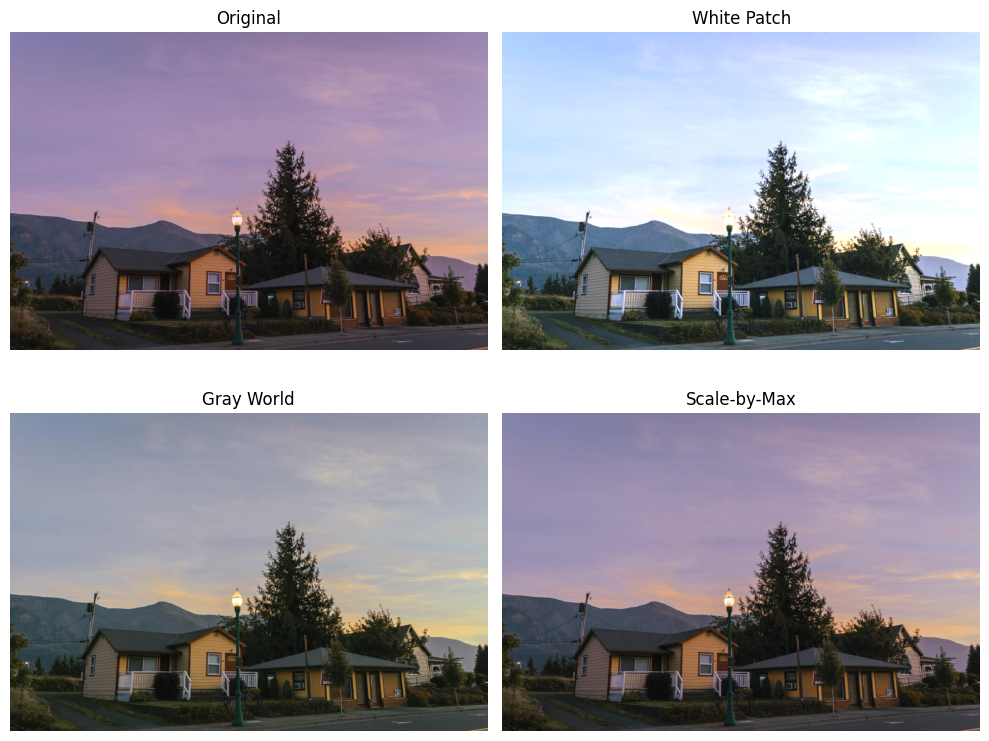

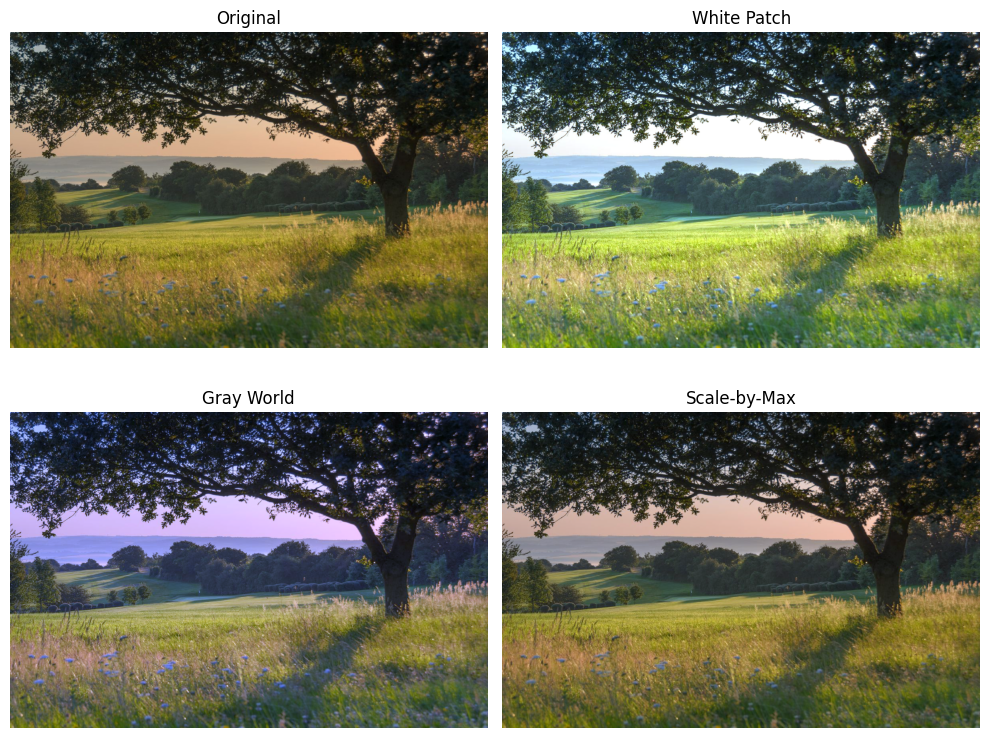

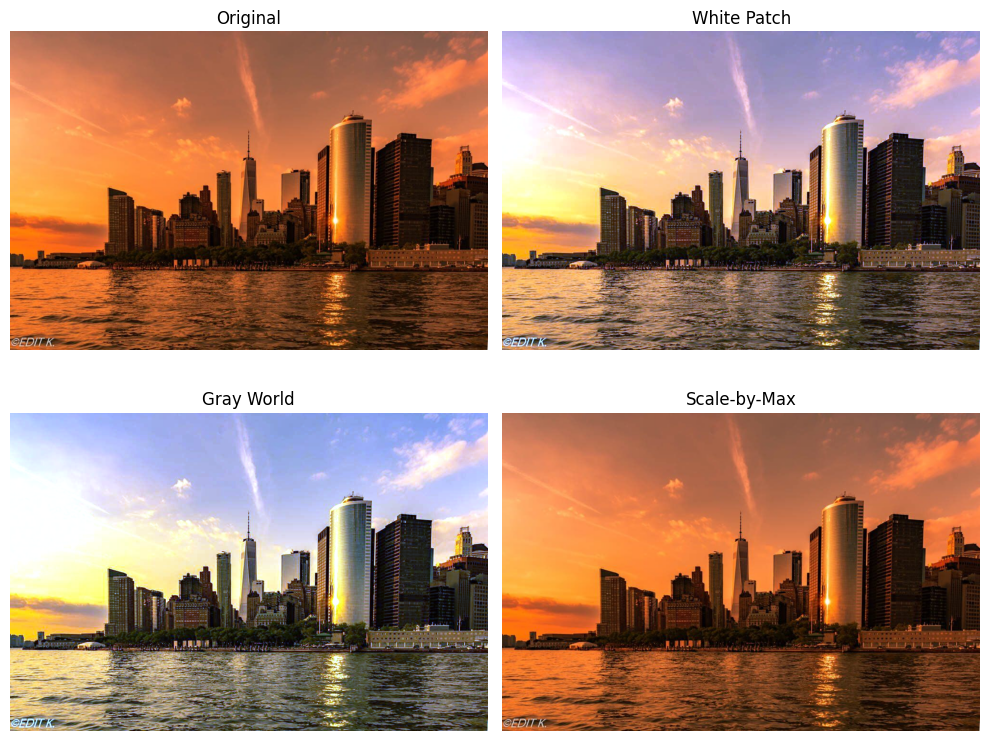

In [186]:
for name, (filename, (row, col)) in images.items():
    
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    compare_balancing(img, row, col)